In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, FloatType




Let’s have a look at the data set first. This dataset contains sensor recordings from different movement activities. X, Y and Z contain accelerometer sensor values whereas the class field contains information about which movement has been recorded. The source field is optional and can be used for data lineage since it contains the file name of the original file where the particular row was imported from.

More details on the data set can be found here: https://github.com/wchill/HMP_Dataset

In [2]:
# Initialize Spark session
spark = SparkSession.builder.appName("HMP_Classification").getOrCreate()



In [3]:
# Directory containing HMP data

spark_df = spark.read.csv("hmp.csv", header=True, inferSchema=True)
spark_df.show(5)


+---+---+---+--------------------+-----------+
|  x|  y|  z|              source|      class|
+---+---+---+--------------------+-----------+
| 22| 49| 35|Accelerometer-201...|Brush_teeth|
| 22| 49| 35|Accelerometer-201...|Brush_teeth|
| 22| 52| 35|Accelerometer-201...|Brush_teeth|
| 22| 52| 35|Accelerometer-201...|Brush_teeth|
| 21| 52| 34|Accelerometer-201...|Brush_teeth|
+---+---+---+--------------------+-----------+
only showing top 5 rows


In [4]:
# Let us look at the schema of the loaded spark dataframe
spark_df.printSchema()

root
 |-- x: integer (nullable = true)
 |-- y: integer (nullable = true)
 |-- z: integer (nullable = true)
 |-- source: string (nullable = true)
 |-- class: string (nullable = true)



In [5]:
spark_df.count()

446529

In [6]:
len(spark_df.columns)

5

In [7]:
# Replace 'column_name' with the name of the column you want unique values for
unique_values = spark_df.select("class").distinct()
unique_values.show()


+--------------+
|         class|
+--------------+
|      Eat_meat|
|     Getup_bed|
|   Drink_glass|
|     Comb_hair|
|  Climb_stairs|
|   Liedown_bed|
|Descend_stairs|
|   Brush_teeth|
|      Eat_soup|
| Use_telephone|
| Standup_chair|
|    Pour_water|
|          Walk|
| Sitdown_chair|
+--------------+



In [8]:
# register a corresponding query table
spark_df.createOrReplaceTempView('spark_df')

In [9]:
#  Using SQL
spark.sql('select class,count(*) from spark_df group by class').show()


+--------------+--------+
|         class|count(1)|
+--------------+--------+
|      Eat_meat|   31236|
|     Getup_bed|   45801|
|   Drink_glass|   42792|
|     Comb_hair|   23504|
|  Climb_stairs|   40258|
|   Liedown_bed|   11446|
|Descend_stairs|   15375|
|   Brush_teeth|   29829|
|      Eat_soup|    6683|
| Use_telephone|   15225|
| Standup_chair|   25417|
|    Pour_water|   41673|
|          Walk|   92254|
| Sitdown_chair|   25036|
+--------------+--------+



In [10]:
# Using DF
spark_df.groupBy('class').count().show()

+--------------+-----+
|         class|count|
+--------------+-----+
|      Eat_meat|31236|
|     Getup_bed|45801|
|   Drink_glass|42792|
|     Comb_hair|23504|
|  Climb_stairs|40258|
|   Liedown_bed|11446|
|Descend_stairs|15375|
|   Brush_teeth|29829|
|      Eat_soup| 6683|
| Use_telephone|15225|
| Standup_chair|25417|
|    Pour_water|41673|
|          Walk|92254|
| Sitdown_chair|25036|
+--------------+-----+



In [11]:
# Group by 'class', count, and order by count
counts = spark_df.groupBy('class').count().orderBy('count').show()

+--------------+-----+
|         class|count|
+--------------+-----+
|      Eat_soup| 6683|
|   Liedown_bed|11446|
| Use_telephone|15225|
|Descend_stairs|15375|
|     Comb_hair|23504|
| Sitdown_chair|25036|
| Standup_chair|25417|
|   Brush_teeth|29829|
|      Eat_meat|31236|
|  Climb_stairs|40258|
|    Pour_water|41673|
|   Drink_glass|42792|
|     Getup_bed|45801|
|          Walk|92254|
+--------------+-----+



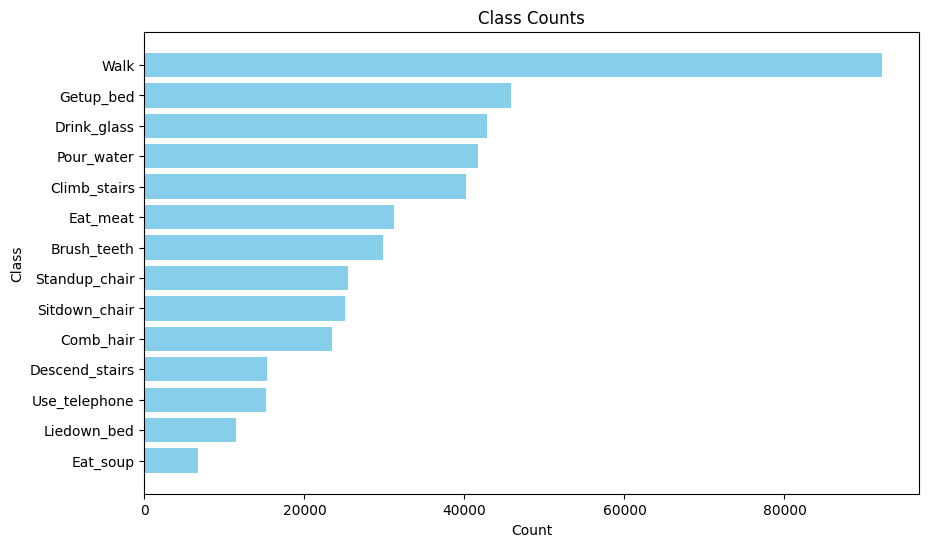

In [12]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

counts = spark_df.groupBy('class').count().orderBy('count')

# Convert Spark DataFrame to Pandas DataFrame for plotting
counts_pd = counts.toPandas()

# Plot using matplotlib
plt.figure(figsize=(10, 6))
plt.barh(counts_pd['class'], counts_pd['count'], color='skyblue')
plt.xlabel("Count")
plt.ylabel("Class")
plt.title("Class Counts")
plt.show()


Imbalanced classes can cause pain in machine learning. Therefore let’s rebalance. In the flowing we limit the number of elements per class to the amount of the least represented class. This is called undersampling.

In [13]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, min, rand, row_number

# 1. Find the size of the smallest class
min_count = spark_df.groupBy('class').count().select(min('count')).first()[0]

# 2. Define a Window: Group by class, and order randomly within each group
window_spec = Window.partitionBy('class').orderBy(rand(seed=42))

# 3. Assign a random row number, filter out the excess, and clean up
df_balanced_new = (spark_df.withColumn("random_row_num", row_number().over(window_spec)).filter(col("random_row_num") <= min_count).drop("random_row_num"))

In [14]:
df_balanced_new.groupBy('class').count().show()

+--------------+-----+
|         class|count|
+--------------+-----+
|     Comb_hair| 6683|
|   Drink_glass| 6683|
|      Eat_meat| 6683|
|     Getup_bed| 6683|
|    Pour_water| 6683|
| Standup_chair| 6683|
| Use_telephone| 6683|
|   Brush_teeth| 6683|
|  Climb_stairs| 6683|
|Descend_stairs| 6683|
|      Eat_soup| 6683|
|   Liedown_bed| 6683|
| Sitdown_chair| 6683|
|          Walk| 6683|
+--------------+-----+



In [15]:
df_balanced_new.show()

+---+---+---+--------------------+---------+
|  x|  y|  z|              source|    class|
+---+---+---+--------------------+---------+
| 11| 38| 34|Accelerometer-201...|Comb_hair|
| 53|  1| 49|Accelerometer-201...|Comb_hair|
| 12| 37| 36|Accelerometer-201...|Comb_hair|
| 36| 19| 57|Accelerometer-201...|Comb_hair|
| 60| 19| 51|Accelerometer-201...|Comb_hair|
| 40| 17| 28|Accelerometer-201...|Comb_hair|
| 12| 35| 33|Accelerometer-201...|Comb_hair|
| 41| 38| 60|Accelerometer-201...|Comb_hair|
| 33| 37| 53|Accelerometer-201...|Comb_hair|
| 13| 40| 34|Accelerometer-201...|Comb_hair|
| 12| 37| 33|Accelerometer-201...|Comb_hair|
| 42| 42| 46|Accelerometer-201...|Comb_hair|
| 29| 17| 32|Accelerometer-201...|Comb_hair|
| 13| 37| 34|Accelerometer-201...|Comb_hair|
| 27| 39| 48|Accelerometer-201...|Comb_hair|
| 35| 34| 41|Accelerometer-201...|Comb_hair|
| 39| 46| 43|Accelerometer-201...|Comb_hair|
| 42| 41| 49|Accelerometer-201...|Comb_hair|
| 44| 53| 53|Accelerometer-201...|Comb_hair|
| 23| 41| 

In [16]:
6683*14

93562

In [17]:
df_balanced_new.count()

93562

In [18]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Convert activity labels to numeric index
indexer = StringIndexer(inputCol="class", outputCol="label")
df_balanced_new = indexer.fit(df_balanced_new).transform(df_balanced_new)
df_balanced_new.show(5)

+---+---+---+--------------------+---------+-----+
|  x|  y|  z|              source|    class|label|
+---+---+---+--------------------+---------+-----+
| 11| 38| 34|Accelerometer-201...|Comb_hair|  2.0|
| 53|  1| 49|Accelerometer-201...|Comb_hair|  2.0|
| 12| 37| 36|Accelerometer-201...|Comb_hair|  2.0|
| 36| 19| 57|Accelerometer-201...|Comb_hair|  2.0|
| 60| 19| 51|Accelerometer-201...|Comb_hair|  2.0|
+---+---+---+--------------------+---------+-----+
only showing top 5 rows


In [19]:
# Assemble features into a single vector
assembler = VectorAssembler(inputCols=["x", "y", "z"], outputCol="features")
df_balanced_new = assembler.transform(df_balanced_new)
df_balanced_new.show(5)



+---+---+---+--------------------+---------+-----+----------------+
|  x|  y|  z|              source|    class|label|        features|
+---+---+---+--------------------+---------+-----+----------------+
| 11| 38| 34|Accelerometer-201...|Comb_hair|  2.0|[11.0,38.0,34.0]|
| 53|  1| 49|Accelerometer-201...|Comb_hair|  2.0| [53.0,1.0,49.0]|
| 12| 37| 36|Accelerometer-201...|Comb_hair|  2.0|[12.0,37.0,36.0]|
| 36| 19| 57|Accelerometer-201...|Comb_hair|  2.0|[36.0,19.0,57.0]|
| 60| 19| 51|Accelerometer-201...|Comb_hair|  2.0|[60.0,19.0,51.0]|
+---+---+---+--------------------+---------+-----+----------------+
only showing top 5 rows


In [20]:
# Select only required columns
data = df_balanced_new.select("features", "label")
data.show(5)

+----------------+-----+
|        features|label|
+----------------+-----+
|[11.0,38.0,34.0]|  2.0|
| [53.0,1.0,49.0]|  2.0|
|[12.0,37.0,36.0]|  2.0|
|[36.0,19.0,57.0]|  2.0|
|[60.0,19.0,51.0]|  2.0|
+----------------+-----+
only showing top 5 rows


In [21]:
# Split data into training and test sets (80-20)
train_data, test_data = data.randomSplit([0.8, 0.2], seed=1234)


In [22]:
train_data.show()

+---------------+-----+
|       features|label|
+---------------+-----+
|[0.0,10.0,28.0]|  7.0|
|[0.0,31.0,17.0]| 11.0|
|[0.0,32.0,23.0]|  7.0|
|[0.0,37.0,35.0]| 11.0|
|[0.0,39.0,27.0]|  7.0|
|[0.0,43.0,34.0]| 11.0|
|[1.0,29.0,23.0]| 11.0|
|[1.0,29.0,27.0]| 11.0|
|[1.0,32.0,36.0]|  7.0|
|[1.0,34.0,30.0]| 11.0|
|[1.0,40.0,32.0]| 11.0|
|[1.0,41.0,34.0]|  7.0|
|[1.0,42.0,43.0]|  7.0|
|[1.0,43.0,33.0]| 11.0|
|[1.0,45.0,41.0]| 11.0|
|[1.0,50.0,34.0]| 11.0|
|[2.0,32.0,42.0]|  9.0|
|[2.0,37.0,33.0]|  7.0|
|[2.0,39.0,33.0]| 11.0|
|[3.0,26.0,23.0]| 11.0|
+---------------+-----+
only showing top 20 rows


In [23]:
test_data.show()

+---------------+-----+
|       features|label|
+---------------+-----+
|[0.0,30.0,24.0]| 11.0|
|[0.0,35.0,28.0]| 11.0|
|[2.0,50.0,31.0]| 11.0|
|[3.0,33.0,30.0]| 11.0|
|[3.0,36.0,22.0]| 11.0|
|[3.0,36.0,30.0]| 11.0|
|[3.0,40.0,33.0]|  7.0|
|[4.0,32.0,30.0]| 11.0|
|[5.0,30.0,33.0]| 11.0|
|[5.0,34.0,18.0]| 11.0|
|[5.0,36.0,25.0]| 11.0|
|[5.0,42.0,32.0]| 11.0|
|[5.0,49.0,38.0]|  2.0|
|[6.0,24.0,13.0]|  7.0|
|[6.0,29.0,46.0]|  7.0|
|[6.0,31.0,25.0]|  7.0|
|[6.0,33.0,30.0]|  7.0|
|[6.0,34.0,30.0]| 11.0|
|[6.0,35.0,30.0]| 11.0|
|[6.0,38.0,36.0]|  7.0|
+---------------+-----+
only showing top 20 rows


In [24]:
from pyspark.ml.classification import LogisticRegression


# Initialize and train the Logistic Regression model
lr = LogisticRegression(maxIter=10, regParam=0.3, elasticNetParam=0.8)
lr_model = lr.fit(train_data)

# Make predictions
lr_predictions = lr_model.transform(test_data)
lr_predictions.select("features", "label", "prediction").show(5)


+---------------+-----+----------+
|       features|label|prediction|
+---------------+-----+----------+
|[0.0,30.0,24.0]| 11.0|       8.0|
|[0.0,35.0,28.0]| 11.0|       8.0|
|[2.0,50.0,31.0]| 11.0|       8.0|
|[3.0,33.0,30.0]| 11.0|       8.0|
|[3.0,36.0,22.0]| 11.0|       8.0|
+---------------+-----+----------+
only showing top 5 rows


In [25]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# Evaluation
evaluator = MulticlassClassificationEvaluator(metricName="accuracy")
lr_accuracy = evaluator.evaluate(lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy}")

Logistic Regression Accuracy: 0.06793217446944652


In [26]:
from pyspark.ml.classification import DecisionTreeClassifier

# Initialize and train Decision Tree Classifier model
dt = DecisionTreeClassifier()
dt_model = dt.fit(train_data)

# Predictions
dt_predictions = dt_model.transform(test_data)

# Evaluation
dt_accuracy = evaluator.evaluate(dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy}")


Decision Tree Accuracy: 0.36744161245600937


In [27]:
from pyspark.ml.classification import RandomForestClassifier

# Initialize and train Random Forest Classifier model
rf = RandomForestClassifier()
rf_model = rf.fit(train_data)

# Predictions
rf_predictions = rf_model.transform(test_data)

# Evaluation
rf_accuracy = evaluator.evaluate(rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy}")


Random Forest Accuracy: 0.3776794283886104


In [28]:
from pyspark.ml.classification import NaiveBayes

# Initialize and train Naive Bayes model
nb = NaiveBayes()
nb_model = nb.fit(train_data)

# Predictions
nb_predictions = nb_model.transform(test_data)

# Evaluation
nb_accuracy = evaluator.evaluate(nb_predictions)
print(f"Naive Bayes Accuracy: {nb_accuracy}")

Naive Bayes Accuracy: 0.2729551029113789


In [29]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Define the layers: input layer (number of features), hidden layers, output layer (number of classes)
layers = [train_data.select("features").first()[0].size, 10, 5, len(train_data.select("label").distinct().collect())]

# Initialize and train Multilayer Perceptron Classifier model
mlp = MultilayerPerceptronClassifier(layers=layers, blockSize=128, seed=1234)
mlp_model = mlp.fit(train_data)

# Predictions
mlp_predictions = mlp_model.transform(test_data)

# Evaluation
mlp_accuracy = evaluator.evaluate(mlp_predictions)
print(f"Multilayer Perceptron Accuracy: {mlp_accuracy}")


Multilayer Perceptron Accuracy: 0.2504532366428495


In [30]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize evaluator for each metric
accuracy_evaluator = MulticlassClassificationEvaluator(metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(metricName="weightedRecall")
f1_evaluator = MulticlassClassificationEvaluator(metricName="f1")

# List to store results
model_metrics = []

# Define models and calculate metrics
for model_name, predictions in [("Logistic Regression", lr_predictions),
                                ("Decision Tree", dt_predictions),
                                ("Random Forest", rf_predictions),
                                ("Multilayer Perceptron", mlp_predictions),
                                ("Naive Bayes", nb_predictions)]:
    accuracy = accuracy_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    model_metrics.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert to Pandas DataFrame
metrics_df = pd.DataFrame(model_metrics)
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.067932,0.004615,0.067932,0.008642
1,Decision Tree,0.367442,0.335027,0.367442,0.317597
2,Random Forest,0.377679,0.343727,0.377679,0.324858
3,Multilayer Perceptron,0.250453,0.247507,0.250453,0.182489
4,Naive Bayes,0.272955,0.238949,0.272955,0.236078


<Figure size 1200x800 with 0 Axes>

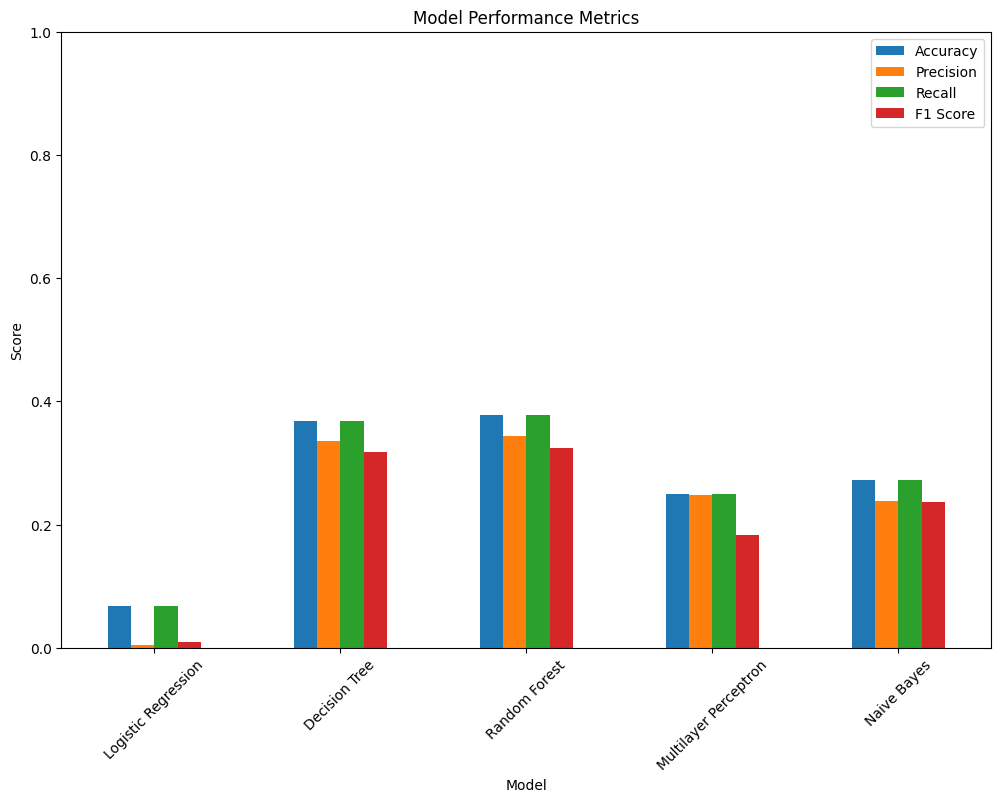

In [31]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 8))

# Plot each metric
metrics_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(12, 8))

# Adding plot details
plt.title("Model Performance Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(loc="upper right")
plt.ylim(0, 1)  # Since scores are usually between 0 and 1
plt.xticks(rotation=45)
plt.show()
